# Importing Necessary Libraries

In [1]:
import os 
import cv2 
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics import classification_report, confusion_matrix 
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

In [2]:
Img_size=224

# Load Model

In [4]:
# Load without compiling the old optimizer (this bypasses the error)
model = tf.keras.models.load_model(
    "/Users/utkarshnageshwar/pneumonia-classification-app-main/model/classifier_model.keras",
    compile=False
)

# Re-compile (only needed if you want to use model.evaluate())
model.compile(
    optimizer=tf.keras.optimizers.Adam(),   # or Adam(learning_rate=0.001) if you had custom LR
    loss='binary_crossentropy',             # change to 'categorical_crossentropy' if you used 2 classes with softmax
    metrics=['accuracy']
)

print("✅ Model loaded successfully!")
model.summary()

2026-04-02 15:24:21.086227: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-02 15:24:21.086404: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-02 15:24:21.086425: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-02 15:24:21.086799: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-02 15:24:21.087193: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Model loaded successfully!
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b2 (Functio  (None, 7, 7, 1408)        8769374   
 nal)                                                            
                                                                 
 global_average_pooling2d (  (None, 1408)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1024)              1442816   
                                                                 
 batch_normalization (Batch  (None, 1024)              4096      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                           

# Load Data

In [5]:
classes=["PNEUMONIA", "NORMAL"]

In [7]:
x, y= [], []
for idx, cls in enumerate(classes):
    folder = f"/Users/utkarshnageshwar/pneumonia-classification-app-main/chest_xray/train/{cls}"
    for name in os.listdir(folder):
        if name.lower().endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(folder, name)
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (Img_size, Img_size))
            x.append(img)
            y.append(idx)

x = np.array(x)
x=preprocess_input(x)
y = np.array(y)

# Model Evaluation

# Model Accuracy

In [8]:
num_classes = 2
y_encoded = tf.keras.utils.to_categorical(y, num_classes)

In [9]:
loss, acc = model.evaluate(x, y_encoded)
print("Test Accuracy:", acc)

2026-04-02 15:25:16.087728: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


163/163 [==============================] - 24s 132ms/step - loss: 0.1825 - accuracy: 0.9582
Test Accuracy: 0.95820552110672


# Classification Report

In [10]:
pred = model.predict(x)
pred = np.argmax(pred, axis=1)

2026-04-02 15:25:40.251392: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


163/163 [==============================] - 22s 127ms/step


In [11]:
print(classification_report(y, pred, target_names=classes))

              precision    recall  f1-score   support

   PNEUMONIA       0.99      0.95      0.97      3875
      NORMAL       0.87      0.99      0.92      1341

    accuracy                           0.96      5216
   macro avg       0.93      0.97      0.95      5216
weighted avg       0.96      0.96      0.96      5216



# Confusion Matrix

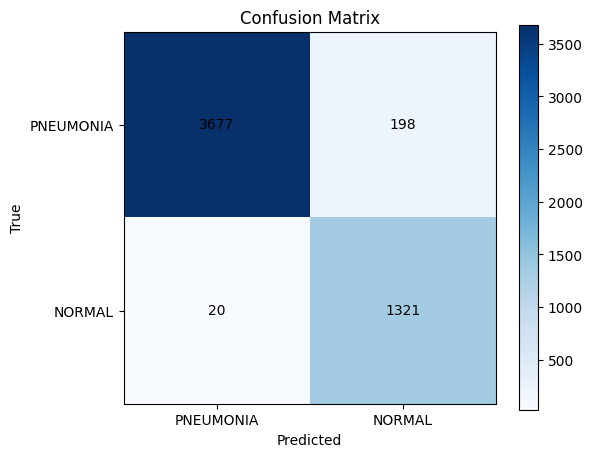

In [12]:
cm = confusion_matrix(y, pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(2), classes)
plt.yticks(range(2), classes)

plt.xlabel("Predicted")
plt.ylabel("True")

# ✅ Fix here
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

2026-04-02 15:26:12.331321: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 1s/step


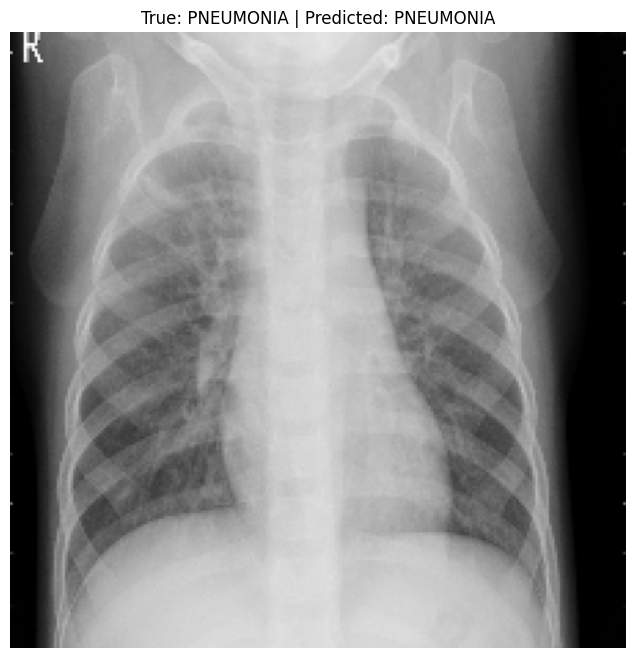

1/1 [==============================] - 0s 23ms/step


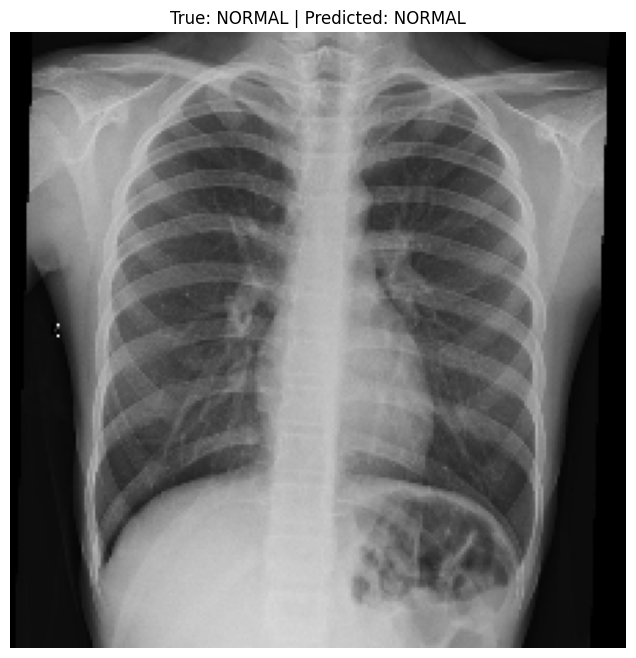

In [14]:
base_path = "/Users/utkarshnageshwar/pneumonia-classification-app-main/chest_xray/test"

for cls in classes:

    img_name = os.listdir(os.path.join(base_path, cls))[np.random.randint(0, 10)]
    img_path = os.path.join(base_path, cls, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (Img_size, Img_size))


    x = np.expand_dims(img, axis=0)
    x = preprocess_input(x)
    pred = model.predict(x)
    pred_class = classes[np.argmax(pred)]

    plt.figure(figsize=(12,8))
    plt.imshow(img)
    plt.title(f"True: {cls} | Predicted: {pred_class}")
    plt.axis("off")
    plt.show()